## Importation of libraries



In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Exploratory Data Analysis (EDA)



read the files and print the head to confirm it

In [155]:
df = pd.read_csv("/content/MY2015 Fuel Consumption Ratings.csv")
df.head()

,Year,Make,Model,Vehicle Class,Engine Size (L),Cylinders,Transmission,Fuel Type,Fuel Consumption (City) (L/100 km),Fuel Consumption (Hwy) (L/100 km),Fuel Consumption (Comb) (L/100 km),Fuel Consumption (Comb) (mpg),CO2 Emissions (g/km),CO2 Rating,Smog Rating
0,2015,ACURA,ILX,COMPACT,2.0,4.0,AS5,Z,9.7,6.7,8.3,34.0,191.0,NaN,NaN
1,2015,ACURA,ILX,COMPACT,2.4,4.0,M6,Z,10.8,7.4,9.3,30.0,214.0,NaN,NaN
2,2015,ACURA,ILX HYBRID,COMPACT,1.5,4.0,AV7,Z,6.0,6.1,6.1,46.0,140.0,NaN,NaN
3,2015,ACURA,MDX SH-AWD,SUV - SMALL,3.5,6.0,AS6,Z,12.7,9.1,11.1,25.0,255.0,NaN,NaN
4,2015,ACURA,RDX AWD,SUV - SMALL,3.5,6.0,AS6,Z,12.1,8.7,10.6,27.0,244.0,NaN,NaN


Check

In [156]:
print(df.columns)

Index(['Year', 'Make', 'Model', 'Vehicle Class', 'Engine Size (L)',
       'Cylinders', 'Transmission', 'Fuel Type',
       'Fuel Consumption (City) (L/100 km)',
       'Fuel Consumption (Hwy) (L/100 km)',
       'Fuel Consumption (Comb) (L/100 km)', 'Fuel Consumption (Comb) (mpg)',
       'CO2 Emissions (g/km)', 'CO2 Rating', 'Smog Rating'],
      dtype='object')


## Removing Columns to Prevent Data Leakage

Although the dataset contains **CO2 Rating** and **Smog Rating**, these variables are derived from vehicle emission measurements rather than intrinsic vehicle characteristics. Since the objective of this project is to predict **CO₂ emissions**, including these rating variables would introduce **data leakage**, allowing the model to learn from information that would not be available when making predictions for new vehicles.


In [157]:
df = df.drop(columns=["CO2 Rating", "Smog Rating"])
df.info()
df.describe()
df.columns
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Year                                1141 non-null   object 
 1   Make                                1147 non-null   object 
 2   Model                               1132 non-null   object 
 3   Vehicle Class                       1132 non-null   object 
 4   Engine Size (L)                     1132 non-null   float64
 5   Cylinders                           1132 non-null   float64
 6   Transmission                        1132 non-null   object 
 7   Fuel Type                           1132 non-null   object 
 8   Fuel Consumption (City) (L/100 km)  1132 non-null   float64
 9   Fuel Consumption (Hwy) (L/100 km)   1132 non-null   float64
 10  Fuel Consumption (Comb) (L/100 km)  1132 non-null   float64
 11  Fuel Consumption (Comb) (mpg)       1132 no

#Check for missing values

In [158]:
df.isnull().sum()

,0
Year,12
Make,6
Model,21
Vehicle Class,21
Engine Size (L),21
Cylinders,21
Transmission,21
Fuel Type,21
Fuel Consumption (City) (L/100 km),21
Fuel Consumption (Hwy) (L/100 km),21


#Renaming the column to ease processing and visualization

In [159]:
df = df.rename(columns={
    "Year": "year",
    "Make": "make",
    "Model": "model",
    "Vehicle Class": "vehicle_class",
    "Engine Size (L)": "engine_size",
    "Cylinders": "cylinders",
    "Transmission": "transmission",
    "Fuel Type": "fuel_type",
    "Fuel Consumption (City) (L/100 km)": "fuel_city",
    "Fuel Consumption (Hwy) (L/100 km)": "fuel_hwy",
    "Fuel Consumption (Comb) (L/100 km)": "fuel_comb",
    "Fuel Consumption (Comb) (mpg)": "fuel_mpg",
    "CO2 Emissions (g/km)": "co2"
})

In [160]:
for col in df.columns:
    print(repr(col))

'year'
'make'
'model'
'vehicle_class'
'engine_size'
'cylinders'
'transmission'
'fuel_type'
'fuel_city'
'fuel_hwy'
'fuel_comb'
'fuel_mpg'
'co2'


## Interpretation

The correlation analysis identifies fuel consumption, engine size, and cylinder count as the most influential predictors of CO₂ emissions. These strong linear relationships indicate that the dataset is well suited for regression models, while also highlighting the importance of considering multicollinearity among some predictor variables.

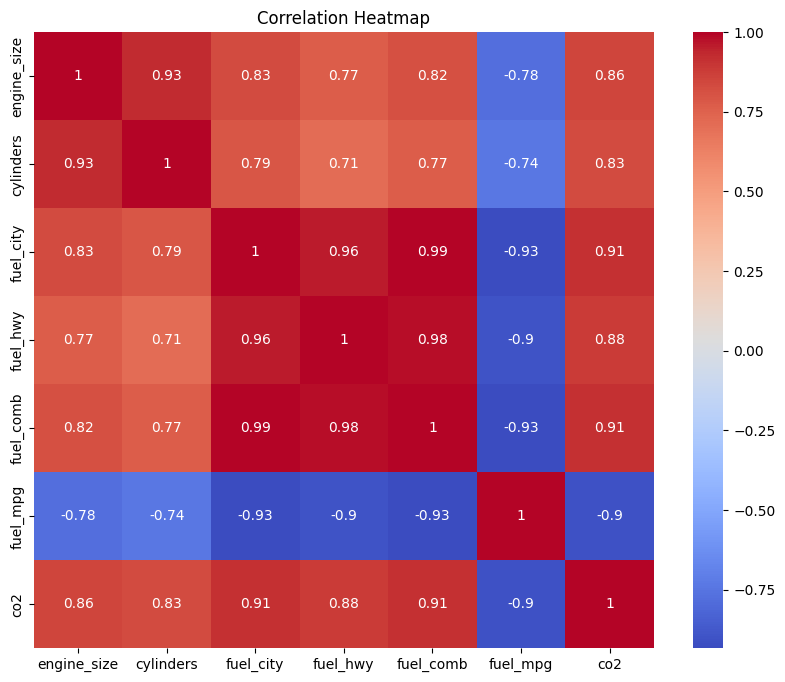

In [161]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Distribution of CO₂ Emissions (Histogram)

The distribution indicates that the dataset covers a broad range of vehicle emission levels while remaining concentrated around moderate values. This variability provides sufficient information for the regression models to learn meaningful relationships between vehicle characteristics and CO₂ emissions.

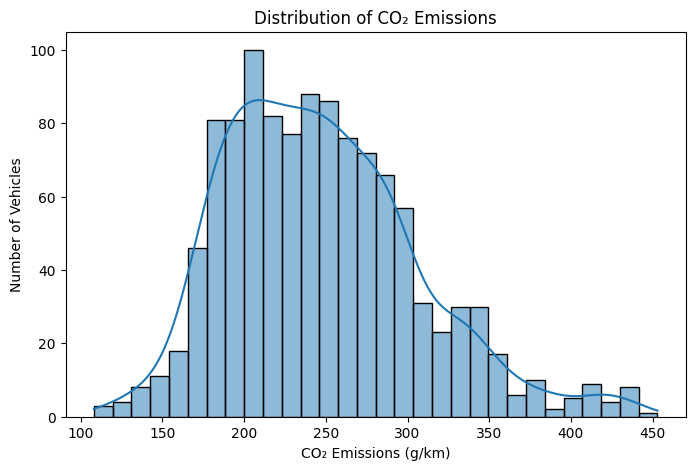

In [162]:
plt.figure(figsize=(8,5))

sns.histplot(df["co2"], bins=30, kde=True)

plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Number of Vehicles")

plt.show()

# Relationship Between Engine Size and CO₂ Emissions (Scatter Plot)
The observed positive trend confirms that engine size is an important predictor of CO₂ emissions. Since the relationship is approximately linear, linear regression is an appropriate modeling technique for this dataset, while other machine learning models can be used for comparison to determine the best-performing algorithm.

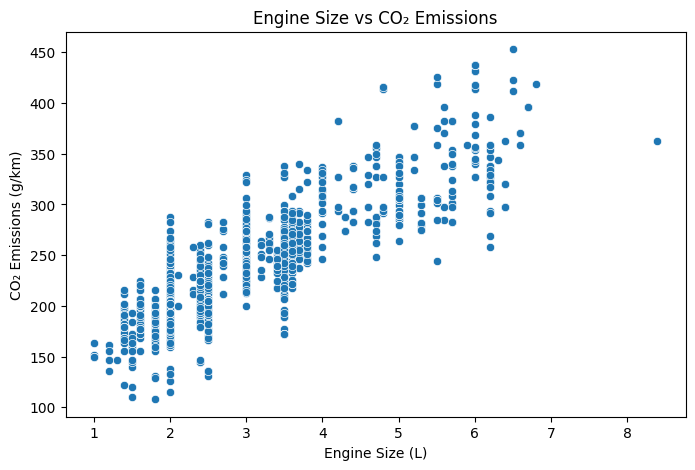

In [163]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="engine_size",
    y="co2"
)

plt.title("Engine Size vs CO₂ Emissions")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO₂ Emissions (g/km)")

plt.show()

# Data Preprocessing

## Objective

Before training the machine learning models, the dataset must be prepared for analysis. This involves converting categorical variables into numerical values, selecting the predictor and target variables, splitting the dataset into training and testing sets, and scaling the numerical features. These preprocessing steps improve model performance and ensure that all algorithms receive data in a suitable format.

In [164]:
# Keep only the actual vehicle records
df = df[df["year"] == "2015"].copy()

# Convert year to an integer
df["year"] = df["year"].astype(int)

# Reset the index
df.reset_index(drop=True, inplace=True)

## 1.Encoding Categorical Variables

Machine learning algorithms require numerical inputs and cannot directly process categorical values such as manufacturer names, transmission types, or fuel types. Label Encoding was therefore applied to transform these categorical variables into numerical representations while preserving all observations in the dataset.

In [165]:
from sklearn.preprocessing import LabelEncoder

# Create label encoders
le_make = LabelEncoder()
le_model = LabelEncoder()
le_vehicle = LabelEncoder()
le_transmission = LabelEncoder()
le_fuel = LabelEncoder()

# Encode categorical columns
df["make"] = le_make.fit_transform(df["make"])
df["model"] = le_model.fit_transform(df["model"])
df["vehicle_class"] = le_vehicle.fit_transform(df["vehicle_class"])
df["transmission"] = le_transmission.fit_transform(df["transmission"])
df["fuel_type"] = le_fuel.fit_transform(df["fuel_type"])

df.head()

,year,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_city,fuel_hwy,fuel_comb,fuel_mpg,co2
0,2015,0,355,0,2.0,4.0,11,3,9.7,6.7,8.3,34.0,191.0
1,2015,0,355,0,2.4,4.0,21,3,10.8,7.4,9.3,30.0,214.0
2,2015,0,356,0,1.5,4.0,18,3,6.0,6.1,6.1,46.0,140.0
3,2015,0,422,11,3.5,6.0,12,3,12.7,9.1,11.1,25.0,255.0
4,2015,0,529,11,3.5,6.0,12,3,12.1,8.7,10.6,27.0,244.0


## 2.Feature Selection

The predictor variables (`X`) consist of all vehicle characteristics, while the target variable (`y`) is the measured CO₂ emissions expressed in grams per kilometre. The objective of the regression models is to learn the relationship between these vehicle characteristics and their corresponding carbon emissions.

In [166]:
X = df.drop(columns=["co2"])

y = df["co2"]

print(X.shape)
print(y.shape)

(1132, 12)
(1132,)


## 3.Splitting the Dataset

The dataset was divided into training and testing subsets using an 80:20 ratio. The training data is used to build the regression models, while the testing data is reserved for evaluating how well the models generalize to previously unseen data.

In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (905, 12)
Testing samples: (227, 12)


##  4.Feature Scaling

The numerical predictor variables were standardized using the StandardScaler technique. Standardization transforms each feature so that it has a mean of zero and a standard deviation of one. This prevents variables with larger numerical ranges from dominating the learning process and improves the performance of several regression algorithms.

In [168]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Development

## Objective

The objective of this section is to train and compare multiple regression algorithms for predicting vehicle CO₂ emissions. Four machine learning models are evaluated using standard regression metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). The model with the best predictive performance will be selected and saved for deployment.

In [169]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [170]:
models = {
    "Linear Regression": LinearRegression(),
    "SGD Regressor": SGDRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    predictions = model.predict(X_test_scaled)

    # Metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [171]:
results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")

,Model,MAE,MSE,RMSE,R2 Score
3,Random Forest,1.456476,66.880301,8.178038,0.980493
2,Decision Tree,0.995595,76.096916,8.723355,0.977805
1,SGD Regressor,13.217258,428.213198,20.693313,0.875104
0,Linear Regression,12.926559,430.086968,20.738538,0.874558


## Model Performance Evaluation

The performance of each regression algorithm was evaluated using four commonly used regression metrics:

- **Mean Absolute Error (MAE):** Measures the average prediction error.
- **Mean Squared Error (MSE):** Penalizes larger prediction errors more heavily.
- **Root Mean Squared Error (RMSE):** Expresses prediction error in the same units as the target variable.
- **R² Score:** Indicates the proportion of variation in CO₂ emissions explained by the model. Values closer to 1 indicate better predictive performance.

The model with the lowest prediction error and highest R² score was selected as the final deployment model.

#Save the best model

In [172]:
best_model_name = results_df.sort_values("RMSE").iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


Save the model

In [173]:
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

#TEST

In [174]:
sample = X_test.iloc[[0]]

sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)

print("Actual CO₂:", y_test.iloc[0])
print("Predicted CO₂:", prediction[0])

Actual CO₂: 419.0
Predicted CO₂: 408.08


In [175]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_predictions = linear_model.predict(X_test_scaled)

plot_df = pd.DataFrame({
    "engine_size": X_test["engine_size"],
    "actual": y_test,
    "predicted": linear_predictions
})

plot_df = plot_df.sort_values("engine_size")

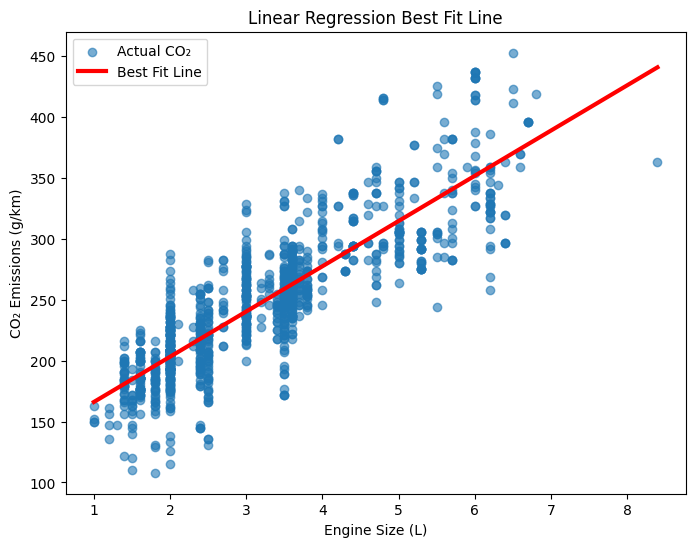

In [176]:
from sklearn.linear_model import LinearRegression

X_line = df[["engine_size"]]
y_line = df["co2"]

line_model = LinearRegression()
line_model.fit(X_line, y_line)

predictions = line_model.predict(X_line)

sorted_index = X_line["engine_size"].argsort()

plt.figure(figsize=(8,6))

plt.scatter(
    X_line["engine_size"],
    y_line,
    alpha=0.6,
    label="Actual CO₂"
)

plt.plot(
    X_line["engine_size"].iloc[sorted_index],
    predictions[sorted_index],
    color="red",
    linewidth=3,
    label="Best Fit Line"
)

plt.xlabel("Engine Size (L)")
plt.ylabel("CO₂ Emissions (g/km)")
plt.title("Linear Regression Best Fit Line")
plt.legend()

plt.show()

In [177]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

linear_model = LinearRegression()
sgd_model = SGDRegressor(random_state=42)
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(random_state=42)

linear_model.fit(X_train_scaled, y_train)
sgd_model.fit(X_train_scaled, y_train)
tree_model.fit(X_train_scaled, y_train)
forest_model.fit(X_train_scaled, y_train)

print("Models trained successfully!")

Models trained successfully!


## Model Comparison and Selection

The four regression models were evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the coefficient of determination (R²).

Among the evaluated models, the **Random Forest Regressor** achieved the best overall performance with the lowest prediction error (MSE = 66.88, RMSE = 8.18) and the highest coefficient of determination (R² = 0.9805). This indicates that the model explains approximately 98% of the variation in vehicle CO₂ emissions while maintaining the smallest prediction errors.

Although Linear Regression and SGD Regressor provided reasonable baseline performance, their prediction errors were considerably higher. The Decision Tree Regressor performed well but was slightly less accurate than the Random Forest model.

Based on these evaluation metrics, the **Random Forest Regressor** was selected as the final model for deployment.

##Save the best model

In [178]:
import joblib

joblib.dump(forest_model, "best_regression_model.pkl")
joblib.dump(scaler, "input_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


##prediction on one test sample

In [179]:
sample = X_test.iloc[[0]]

sample_scaled = scaler.transform(sample)

prediction = forest_model.predict(sample_scaled)

print("Actual CO₂ Emission:", y_test.iloc[0])
print("Predicted CO₂ Emission:", prediction[0])

Actual CO₂ Emission: 419.0
Predicted CO₂ Emission: 408.08
